Name:Wafa Karim Khan

Msc(Data science & Big Data Analytics)

College: B.K Birla College of Arts, Science and Commerce kalyan.

Task4:Handwritten Digit Recognition - Comparing KNN, Random Forest and Decision Tree 

 Import Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


Load MNIST Dataset

In [2]:
mnist = fetch_openml('mnist_784', version=1) #fetches the MNIST dataset using the fetch_openml function.

X, y = mnist["data"], mnist["target"]

# Convert string labels to integers
y = y.astype(np.uint8)


Preprocess the Data

In [3]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
#(Standardization helps algorithms converge faster and prevents features with larger scales 
# from dominating those with smaller scales during the training process.)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #calculates the mean and standard deviation of each feature in the training set.
X_test_scaled = scaler.transform(X_test) # does the same for testing


Implement and Train Models

Training a K-Nearest Neighbors (KNN) classifier.


In [4]:
knn_clf = KNeighborsClassifier(n_neighbors=3) #the classifier will consider the 3 nearest neighbors when making predictions. 
knn_clf.fit(X_train_scaled, y_train) #fit() method to train the model using the training data


KNeighborsClassifier(n_neighbors=3)

Training a Random Forest classifier  
RF: Creates some decision tree where every node represent a decision based on a single feature & take average of all predictions to obtain the final predictions.

In [5]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42) #specifies the number of decision trees in the forest.
rf_clf.fit(X_train_scaled, y_train) #fit() method to train the model using the training data


RandomForestClassifier(random_state=42)

Training a Decision Tree


In [6]:
dt_clf = DecisionTreeClassifier(max_depth=10, random_state=42) #specifies max depth of the decision tree(prevent overfitting).
dt_clf.fit(X_train_scaled, y_train)


DecisionTreeClassifier(max_depth=10, random_state=42)

Evaluate Models

In [13]:
def evaluate_model(clf, X_test, y_test): #Here we evaluate the classifier using feature matrix and target of the test data.
    y_pred = clf.predict(X_test) #This line uses the trained classifier to make predictions on the test data. 
    accuracy = accuracy_score(y_test, y_pred) 
    precision = precision_score(y_test, y_pred, average='weighted')   #calculate various evaluation metrics
    recall = recall_score(y_test, y_pred, average='weighted') 
    f1 = f1_score(y_test, y_pred, average='weighted') 
    cm = confusion_matrix(y_test, y_pred) #computes the confusion matrix for the classifier's predictions on the test data. 
    return accuracy, precision, recall, f1, cm #This will  returns the computed evaluation metrics.

# Evaluate KNN
knn_accuracy, knn_precision, knn_recall, knn_f1, knn_cm = evaluate_model(knn_clf, X_test_scaled, y_test)
#This will calculate the performance matrix for knn.

# Evaluate Random Forest
rf_accuracy, rf_precision, rf_recall, rf_f1, rf_cm = evaluate_model(rf_clf, X_test_scaled, y_test)
#This will calculate the performance matrix for rf.

# Evaluate Decision Tree
dt_accuracy, dt_precision, dt_recall, dt_f1, dt_cm = evaluate_model(dt_clf, X_test_scaled, y_test)
#This will calculate the performance matrix for dt.

Compare Model Performance

In [11]:
models = ['KNN', 'Random Forest', 'Decision Tree'] # store the names of the models

#Each list contains the values for KNN, Random Forest, and Decision Tree classifiers.
accuracies = [knn_accuracy, rf_accuracy, dt_accuracy]
precisions = [knn_precision, rf_precision, dt_precision]
recalls = [knn_recall, rf_recall, dt_recall]
f1_scores = [knn_f1, rf_f1, dt_f1]

# Create a DataFrame to summarize the metrics
metrics_df = pd.DataFrame({'Model': models,
                           'Accuracy': accuracies,
                           'Precision': precisions,
                           'Recall': recalls,
                           'F1 Score': f1_scores})

print(metrics_df)


           Model  Accuracy  Precision    Recall  F1 Score
0            KNN  0.946500   0.946690  0.946500  0.946387
1  Random Forest  0.967429   0.967427  0.967429  0.967412
2  Decision Tree  0.858429   0.858908  0.858429  0.858338


Visualize Confusion Matrices

Text(0.5, 1.0, 'Confusion Matrix - KNN')

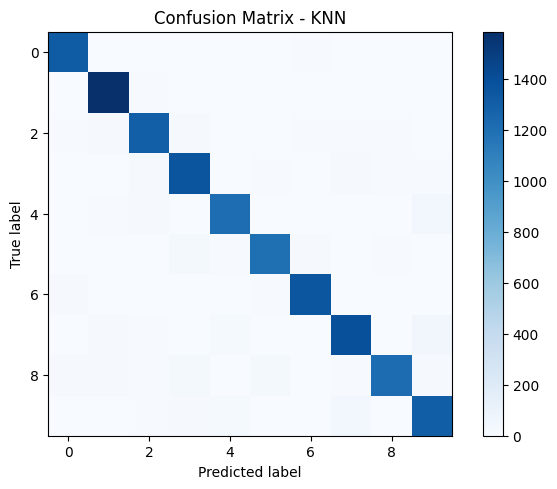

In [17]:
def plot_confusion_matrix(cm, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap) #nearest-neighbor interpolation for smoother visualization.
    plt.title(title)
    plt.colorbar()
    plt.tight_layout() #to prevent overlap between plot elements.
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot Confusion Matrix for KNN
plt.figure()
plot_confusion_matrix(knn_cm)
plt.title('Confusion Matrix - KNN')


Darker colors represent a higher number of correctly classified data points. 
As the color gets lighter, it indicates a decreasing number of correct classifications.
Strengths: Categories where the model excels (dark diagonal cells).
Weaknesses: Categories where the model struggles (lighter off-diagonal cells).
Categories represents classes of handwritten digits.

Observations:
    The KNN model demonstrates relatively high accuracy for digits like 0, 1, and 7, as indicated by the high values on the diagonal.
 KNN performs reasonably well, but it struggles with distinguishing between visually similar digits.

Text(0.5, 1.0, 'Confusion Matrix - Random Forest')

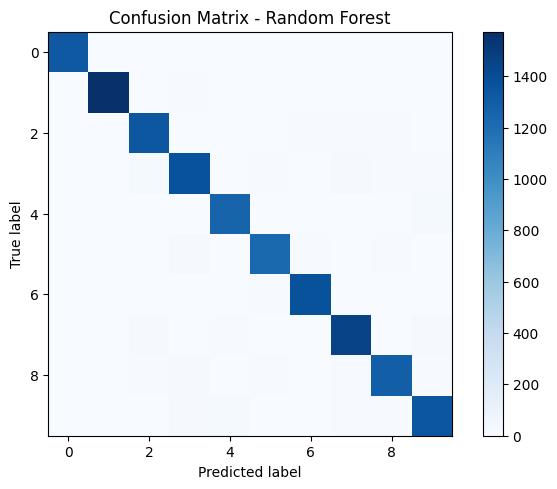

In [14]:
# Plot Confusion Matrix for Random Forest
plt.figure()
plot_confusion_matrix(rf_cm)
plt.title('Confusion Matrix - Random Forest')


Observations:
    Random Forest achieves high accuracy across most digits, with a notable improvement over KNN in terms of reducing confusion between visually similar digits.

Text(0.5, 1.0, 'Confusion Matrix - Decision Tree')

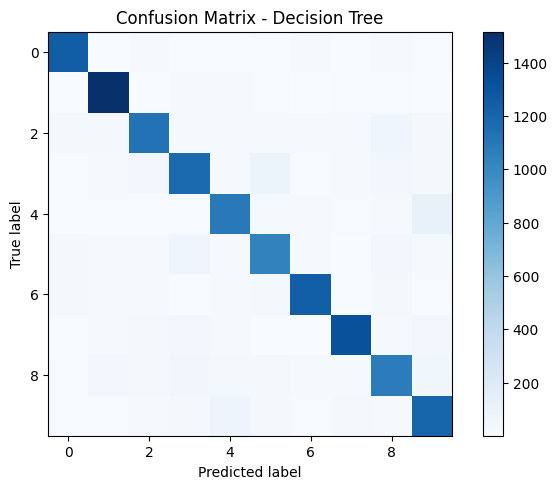

In [15]:
# Plot Confusion Matrix for Decision Tree
plt.figure()
plot_confusion_matrix(dt_cm)
plt.title('Confusion Matrix - Decision Tree')


Observations:
    Decision Tree performs adequately but shows signs of overfitting, especially for certain digits.
There is a higher degree of variability in performance across different digits compared to KNN and Random Forest.

Result:
    Random Forest demonstrates the highest overall accuracy and exhibits better performance compared to KNN and Decision Tree.